## Uncertainty quantification of tranmission coefficients with KDUQ 

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Latex, Math, display
from periodictable import elements

In [2]:
from matplotlib import pyplot as plt

## Compare models to KD

In [3]:
A, Z = (24, 12)

In [4]:
name_core = str(elements[Z].symbol)
display(Math(f"^{{{A}}} \\rm{{{name_core}}}"))

<IPython.core.display.Math object>

## Transmission coefficients
Let's use `jitr` to calculate UQ'ed transmission coefficients using KDUQ Fermi energies and those from a variety of mass models

In [5]:
from tqdm import tqdm

import jitr

In [6]:
neutron = (1, 0)
proton = (1, 1)
projectile = proton
target = (A, Z)

In [7]:
# we have 416 samples from the KDUQ posterior
kduq_omp_samples = jitr.optical_potentials.kduq.get_samples(proton)

In [8]:
# com_energy_grid = np.logspace(-1, 1.3, 100)
lab_energy_grid = np.array([65, 200])
range_fm = 15
lmax = 20

In [9]:
reaction = jitr.reactions.Reaction(target=target, projectile=projectile, process="EL")

In [11]:
def set_up_grid(core, lab_energy_grid):
    solvers = []
    for i, Elab in enumerate(tqdm(lab_energy_grid)):
        kinematics = reaction.kinematics(Elab)
        a = range_fm * kinematics.k + np.pi / 2
        N = jitr.utils.suggested_basis_size(a)
        solvers.append(
            jitr.xs.elastic.IntegralWorkspace(
                reaction=reaction,
                kinematics=kinematics,
                channel_radius_fm=a / kinematics.k,
                solver=jitr.rmatrix.Solver(N),
                lmax=lmax,
                smatrix_abs_tol=0,
            )
        )
    return solvers

In [12]:
solvers = set_up_grid(target, lab_energy_grid)

100%|██████████| 2/2 [00:07<00:00,  3.78s/it]


## Run UQ

### KDUQ

In [15]:
tcoeff_kduq = np.zeros((lab_energy_grid.size, kduq_omp_samples.shape[0], 2, lmax))
for j, sample in enumerate(tqdm(kduq_omp_samples)):

    for i, Elab in enumerate(lab_energy_grid):
        central_params, spin_orbit_params, coulomb_params = (
            jitr.optical_potentials.kduq.calculate_params(
                projectile,
                target,
                solvers[i].kinematics.Elab,
                *sample,
            )
        )

        tplus, tminus = solvers[i].transmission_coefficients(
            jitr.optical_potentials.kduq.central,
            jitr.optical_potentials.kduq.spin_orbit,
            jitr.optical_potentials.kduq.coulomb_charged_sphere,
            central_params,
            spin_orbit_params,
            coulomb_params,
        )
        tcoeff_kduq[i, j, 0, :] = tplus
        tcoeff_kduq[i, j, 1, :] = tminus

 96%|█████████▋| 401/416 [00:21<00:00, 47.58it/s]/mnt/ffs24/home/beyerkyl/jitr/src/jitr/optical_potentials/kduq.py:481: RuntimeWarning: overflow encountered in exp
  d2 = d2_0 + d2_A / (1 + np.exp((A - d2_A3) / d2_A2))
100%|██████████| 416/416 [00:21<00:00, 19.17it/s]


In [16]:
data = [np.zeros(20)] * 8
names = [
    "E=65 MeV, j = l + 1/2",
    "E=65 MeV, j = l - 1/2",
    "E=65 MeV, j = l + 1/2, err",
    "E=65 MeV, j = l - 1/2, err",
    "E=200 MeV, j = l + 1/2",
    "E=200 MeV, j = l - 1/2",
    "E=200 MeV, j = l + 1/2, err",
    "E=200 MeV, j = l - 1/2, err",
]

In [17]:
from pandas import DataFrame as df

In [18]:
data = df.from_dict(dict(zip(names, data)))

In [19]:
plus_color = "tab:blue"
minus_color = "tab:orange"

In [20]:
ci_plus = np.percentile(tcoeff_kduq[0, :, 0, :], 50, axis=0)
ci_plus_errs = np.percentile(tcoeff_kduq[0, :, 0, :], 84, axis=0) - np.percentile(
    tcoeff_kduq[0, :, 0, :], 16, axis=0
)

In [21]:
ci_minus = np.percentile(tcoeff_kduq[0, :, 1, :], 50, axis=0)
ci_minus_errs = np.percentile(tcoeff_kduq[0, :, 1, :], 84, axis=0) - np.percentile(
    tcoeff_kduq[0, :, 1, :], 16, axis=0
)

In [22]:
ci_minus[0] = None
ci_minus_errs[0] = None

In [23]:
data["E=65 MeV, j = l + 1/2"] = ci_plus
data["E=65 MeV, j = l + 1/2, err"] = ci_plus_errs
data["E=65 MeV, j = l - 1/2"] = ci_minus
data["E=65 MeV, j = l - 1/2, err"] = ci_minus_errs

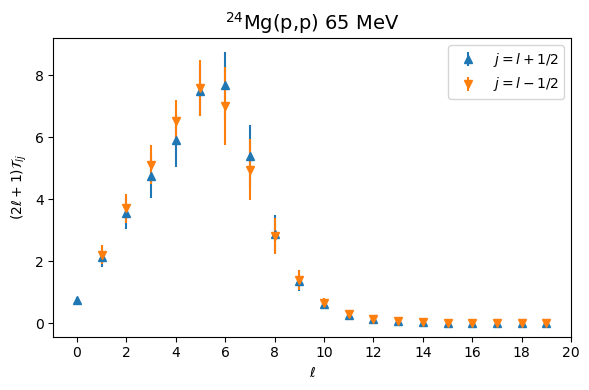

In [24]:
fig = plt.figure(figsize=(6, 4))
ls = np.arange(lmax)
plt.errorbar(
    ls,
    ci_plus * (2 * ls + 1),
    ci_plus_errs * (2 * ls + 1),
    linestyle="none",
    marker="^",
    label="$j = l + 1/2$",
)

plt.errorbar(
    ls[1:],
    ci_minus[1:] * (2 * ls[1:] + 1),
    ci_minus_errs[1:] * (2 * ls[1:] + 1),
    linestyle="none",
    marker="v",
    label="$j = l - 1/2$",
)

# plt.yscale("log")
plt.xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
plt.xlabel(r"$\ell$")
plt.ylabel(r"$(2  \ell +1) \mathcal{T}_{lj}$")
plt.title(r"$^{24}$Mg(p,p) 65 MeV", fontsize=14)
plt.legend()
plt.tight_layout()

In [25]:
ci_plus = np.percentile(tcoeff_kduq[1, :, 0, :], 50, axis=0)
ci_plus_errs = np.percentile(tcoeff_kduq[1, :, 0, :], 84, axis=0) - np.percentile(
    tcoeff_kduq[1, :, 0, :], 16, axis=0
)

In [26]:
ci_minus = np.percentile(tcoeff_kduq[1, :, 1, :], 50, axis=0)
ci_minus_errs = np.percentile(tcoeff_kduq[1, :, 1, :], 84, axis=0) - np.percentile(
    tcoeff_kduq[1, :, 1, :], 16, axis=0
)
ci_minus[0] = None
ci_minus_errs[0] = None

In [27]:
data["E=200 MeV, j = l + 1/2"] = ci_plus
data["E=200 MeV, j = l + 1/2, err"] = ci_plus_errs
data["E=200 MeV, j = l - 1/2"] = ci_minus
data["E=200 MeV, j = l - 1/2, err"] = ci_minus_errs

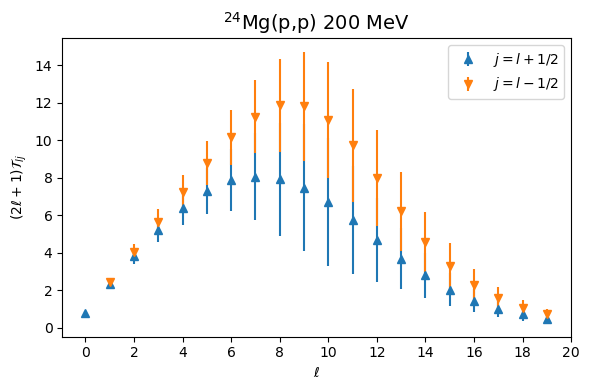

In [28]:
fig = plt.figure(figsize=(6, 4))
ls = np.arange(lmax)
plt.errorbar(
    ls,
    ci_plus * (2 * ls + 1),
    ci_plus_errs * (2 * ls + 1),
    linestyle="none",
    marker="^",
    label="$j = l + 1/2$",
)

plt.errorbar(
    ls[1:],
    ci_minus[1:] * (2 * ls[1:] + 1),
    ci_minus_errs[1:] * (2 * ls[1:] + 1),
    linestyle="none",
    marker="v",
    label="$j = l - 1/2$",
)

# plt.yscale("log")
plt.xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
plt.xlabel(r"$\ell$")
plt.ylabel(r"$(2  \ell +1) \mathcal{T}_{lj}$")
plt.title(r"$^{24}$Mg(p,p) 200 MeV", fontsize=14)
plt.legend()
plt.tight_layout()

In [29]:
# NBVAL_CHECK_OUTPUT
data

,"E=65 MeV, j = l + 1/2","E=65 MeV, j = l - 1/2","E=65 MeV, j = l + 1/2, err","E=65 MeV, j = l - 1/2, err","E=200 MeV, j = l + 1/2","E=200 MeV, j = l - 1/2","E=200 MeV, j = l + 1/2, err","E=200 MeV, j = l - 1/2, err"
0,0.732306,NaN,0.103491,NaN,0.793631,NaN,0.083665,NaN
1,0.714397,0.733912,0.106325,0.101622,0.781721,0.806950,0.086771,0.084428
2,0.707490,0.740207,0.101053,0.093985,0.765326,0.809628,0.089057,0.087703
3,0.678968,0.730161,0.100371,0.088427,0.741524,0.808922,0.090451,0.094959
4,0.656383,0.725234,0.095936,0.075356,0.709459,0.804422,0.101630,0.100298
5,0.681355,0.689816,0.074087,0.082002,0.664013,0.797320,0.111231,0.107043
6,0.589953,0.538968,0.083585,0.095931,0.605166,0.781423,0.127492,0.114318
7,0.358919,0.329351,0.067499,0.065663,0.537147,0.751475,0.154021,0.130638
8,0.169756,0.165448,0.035843,0.034335,0.465712,0.698140,0.178390,0.146219
9,0.072202,0.073235,0.017226,0.016429,0.393139,0.621629,0.178045,0.154005
